Thử nghiệm SSIM kết hợp với Reconstruction Loss là MSE

Thử nghiệm Latent traversal để tìm hiểu cụ thể đặc trưng của z là gì

In [2]:
import torch 
import torch.nn as nn

In [3]:
class ResNetBlock(nn.Module):
    def __init__(self, channels: int):
        # Khởi tạo khối ResNet với channels: là số chiều của ảnh đầu vào
        super(ResNetBlock, self).__init__()
        self.channels = channels
        self.num_groups = 8
        # Khởi tạo cho khối thứ 1
        self.norm1 = nn.GroupNorm(num_groups=self.num_groups, num_channels=self.channels)
        self.act1 = nn.SiLU()

        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3,
                               stride=1, padding=1)
        # Khởi tạo cho khối thứ 2
        self.norm2 = nn.GroupNorm(num_groups=self.num_groups, num_channels=self.channels)
        self.act2 = nn.SiLU()

        self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, 
                               stride=1, padding=1)

        
    def forward(self, x):
        residual = x
        # Khối 1
        x = self.norm1(x)
        x = self.act1(x)
        x = self.conv1(x)
        # Khối 2
        x = self.norm2(x)
        x = self.act2(x)
        x = self.conv2(x)

        return x + residual

In [4]:
# Cài đặt Encoder
class Encoder(nn.Module):
    def __init__(self, latent_features: int):
        super(Encoder, self).__init__()
        self.latent_features = latent_features
        self.conv0 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.resnet1 = ResNetBlock(channels=32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.resnet2 = ResNetBlock(channels=64)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.resnet3 = ResNetBlock(channels=128)

        self.conv6 = nn.Conv2d(in_channels=128, out_channels= self.latent_features * 2, kernel_size=3, stride=2, padding = 1)
        
    def forward(self, x):
        x0 = self.conv0(x)
        x1 = self.resnet1(x0)

        x2 = self.conv2(x1)
        x3 = self.resnet2(x2)

        x4 = self.conv4(x3)
        x5 = self.resnet3(x4)
        
        x6 = self.conv6(x5)
        # Sử dụng torch.chunk để chia đôi tensor.
        muy, log_var = torch.chunk(x6, chunks=2, dim= 1)
        # Giải thích: mu và log_var sẽ có shape là (B, latent_features, 32, 32)
        return muy, log_var

In [5]:
# Latent space and reparameterization trick
def reparameterization_trick(mu: torch.Tensor, log_var: torch.Tensor):
    # 1. Lấy độ lệch chuẩn
    stdev = torch.exp(0.5 * log_var)

    # 2. Lấy mẫu nhiễu epsilon từ phân phối chuẩn tắc N(0, 1)
    # Hàm torch.randn_like cực kỳ tiện lợi: nó tự động tạo ra một tensor chứa nhiễu
    # có cùng kích thước (shape), cùng kiểu dữ liệu (dtype) và 
    # nằm trên cùng thiết bị (CPU hay GPU) với tensor `mu`.
    epsilon = torch.randn_like(mu)

    z = mu + stdev * epsilon

    return z

In [6]:
# Decoder
class Decoder(nn.Module):
    def __init__(self, latent_features: int):
        super(Decoder, self).__init__()
        self.latent_features = latent_features
        self.sigmoid = nn.Sigmoid()

        self.conv0 = nn.ConvTranspose2d(in_channels=self.latent_features, out_channels=128, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet1 = ResNetBlock(channels=128)

        self.conv2 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet2 = ResNetBlock(channels=64)

        self.conv4 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet3 = ResNetBlock(channels=32)

        self.conv6 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, 
                                        padding=1)
        
        
    def forward(self, x):
        x0 = self.conv0(x)
        x1 = self.resnet1(x0)

        x2 = self.conv2(x1)
        x3 = self.resnet2(x2)

        x4 = self.conv4(x3)
        x5 = self.resnet3(x4)
        
        logits = self.conv6(x5) # Shape: (B, 3, 256, 256)
        output = self.sigmoid(logits) # Ép giá trị về [0, 1]

        return output

In [7]:
# VAE class
class VAE(nn.Module):
    def __init__(self, latent_features: int):
        super(VAE, self).__init__()
        # Khởi tạo encoder và decoder
        self.encoder = Encoder(latent_features=latent_features)
        self.decoder = Decoder(latent_features=latent_features)
    
    def forward(self, x):
        # Encoder
        mu, log_var = self.encoder(x)
        # Reparameterization trick
        z = reparameterization_trick(mu=mu, log_var=log_var)
        # Decoder
        output = self.decoder(z)
        return output, mu, log_var

In [8]:
import torch.nn.functional as F

In [9]:
import torch
import torch.nn.functional as F
# Import hàm SSIM từ TorchMetrics
# from torchmetrics.functional.image import structural_similarity_index_measure as ssim
from pytorch_msssim import ssim

# Hàm loss
def vae_loss_fn(model, batch, lambda_rec = 1.0, lambda_kl = 1.0, lambda_ssim=0.84):
    # Chạy model
    output, mu, log_var = model(batch)
    # Reconstruction loss: Mean Squared Loss
    reconstruction_loss = F.mse_loss(output, batch, reduction='mean')
    # KL Loss
    kl_loss = 0.5 * torch.sum(mu.pow(2) + log_var.exp() - log_var - 1, dim=(1, 2, 3))
    kl_loss = torch.mean(kl_loss) # Lấy trung bình trên toàn batch
    kl_loss = kl_loss / (4 * 4 * 4)

    # SSIM Loss
    ssim_val = ssim(output, batch, data_range=1.0)
    ssim_loss = 1.0 - ssim_val.mean()
    # Tổng hợp Loss
    total_loss = lambda_rec * reconstruction_loss + lambda_kl * kl_loss + lambda_ssim * ssim_loss
    
    return total_loss

In [10]:
# Train_step
def train_step(optimizer, batch, model, lambda_rec, lambda_kl):
    x = batch['image']
    # Xóa đạo hàm
    optimizer.zero_grad()
    # Forward pass
    total_loss = vae_loss_fn(model=model, batch=x, lambda_rec=lambda_rec, lambda_kl=lambda_kl)

    # Tình đạo hàm
    total_loss.backward()
    # Cập nhật trọng số
    optimizer.step()

    return total_loss.item()

In [11]:
import torch.optim as optim
from tqdm import tqdm

In [12]:

# Vòng lặp huấn luyện
def run_training(model, train_loader, val_loader, config, device):
    model.train()
    model.to(device)

    # Khởi tạo optimizer
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])

    # Vòng lặp epoch
    for epoch_idx in range(config['num_epochs']):
        
        model.train()

        epoch_losses = []

        # tqdm để tạo thanh tiến trình 
        progess_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch_idx+1}/{config['num_epochs']}")

        # Vòng lặp batch
        for i, batch in progess_bar:
            x = batch['image'].to(device)
            # Xóa sạch đạo hàm
            optimizer.zero_grad()
            # Tính loss
            loss = vae_loss_fn(
                model=model,
                batch=x,
                lambda_rec=config['lambda_rec'],
                lambda_kl=config['lambda_kl'],
                lambda_ssim=config['lambda_ssim']
            )
            # Backpropagation
            loss.backward()

            # Cập nhật trọng số
            optimizer.step()

            current_loss = loss.item()
            epoch_losses.append(current_loss)

            # Cập nhật thanh tiến trình
            progess_bar.set_postfix(loss=f"{current_loss:.4f}")
        
        # Tính trung bình loss sau mỗi epoch
        avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch_idx+1} | Train Loss trung bình: {avg_epoch_loss:.4f}\n")

        # Validate model
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device=device)
                # Tính loss
                val_loss = vae_loss_fn(
                    model=model,
                    batch=images,
                    lambda_rec=config['lambda_rec'],
                    lambda_kl=config['lambda_kl'],
                    lambda_ssim=config['lambda_ssim']
                ) 
                total_val_loss += val_loss.item()

        average_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch_idx+1} | Val Loss trung bình: {average_val_loss:.4f}\n")


    print("Huấn luyện xong")
    return model


In [13]:
import yaml
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

c:\Users\ADMIN\duong_env_py10\lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find cuobjdump.exe
  warnings.warn(f"Failed to find {binary}")
c:\Users\ADMIN\duong_env_py10\lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find nvdisasm.exe
  warnings.warn(f"Failed to find {binary}")


In [14]:
from torch.utils.data import DataLoader, random_split
# Xây dựng Wrapper cho Dataset
class MNISTDataset(Dataset):
    def __init__(self, root="./data", train=True, download=False):
        # Đổi kích thước lên 32*32 và chuyển thành Tensor [0, 1]
        self.transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        self.dataset = datasets.MNIST(root=root, train=train, download=download, transform=self.transform)

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        img, label = self.dataset[index]
        return {'image': img, 'label': label}

# Khởi tạo Dataset và Dataloader
full_train_dataset = MNISTDataset(train=True, download=False)
# Chia thành tập train và validate
total_size = len(full_train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
print("=== PHÂN CHIA DỮ LIỆU ===")
print(f"Tổng số ảnh gốc:     {total_size}")
print(f"Số ảnh tập Train:    {len(train_subset)}")
print(f"Số ảnh tập Validate: {len(val_subset)}\n")  

=== PHÂN CHIA DỮ LIỆU ===
Tổng số ảnh gốc:     60000
Số ảnh tập Train:    48000
Số ảnh tập Validate: 12000



In [15]:
train_loader = DataLoader(train_subset, batch_size=config['batch_size'], shuffle=True) # Shuffle tập train
val_loader = DataLoader(dataset=val_subset, batch_size=config['batch_size'], shuffle=False) # Ko shuffle tập val

In [16]:
# Khởi tạo device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device: ", device)

Device:  cuda


In [17]:
# Train kết hợp với Evaluate Model
# Model
model = VAE(latent_features=config['latent_features'])

# Huấn luyện
trained_model = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    device=device
)

Epoch 1/10: 100%|██████████| 375/375 [00:52<00:00,  7.12it/s, loss=0.0396]


Epoch 1 | Train Loss trung bình: 0.0941

Epoch 1 | Val Loss trung bình: 0.0305



Epoch 2/10: 100%|██████████| 375/375 [00:47<00:00,  7.88it/s, loss=0.0212]


Epoch 2 | Train Loss trung bình: 0.0271

Epoch 2 | Val Loss trung bình: 0.0212



Epoch 3/10: 100%|██████████| 375/375 [00:48<00:00,  7.72it/s, loss=0.0184]


...

Epoch 8 | Train Loss trung bình: 0.0137

Epoch 8 | Val Loss trung bình: 0.0130



Epoch 9/10: 100%|██████████| 375/375 [00:47<00:00,  7.94it/s, loss=0.0120]


Epoch 9 | Train Loss trung bình: 0.0129

Epoch 9 | Val Loss trung bình: 0.0117



Epoch 10/10: 100%|██████████| 375/375 [00:49<00:00,  7.55it/s, loss=0.0128]


Epoch 10 | Train Loss trung bình: 0.0127

Epoch 10 | Val Loss trung bình: 0.0129

Huấn luyện xong


So sánh ảnh gốc với ảnh được tái tạo

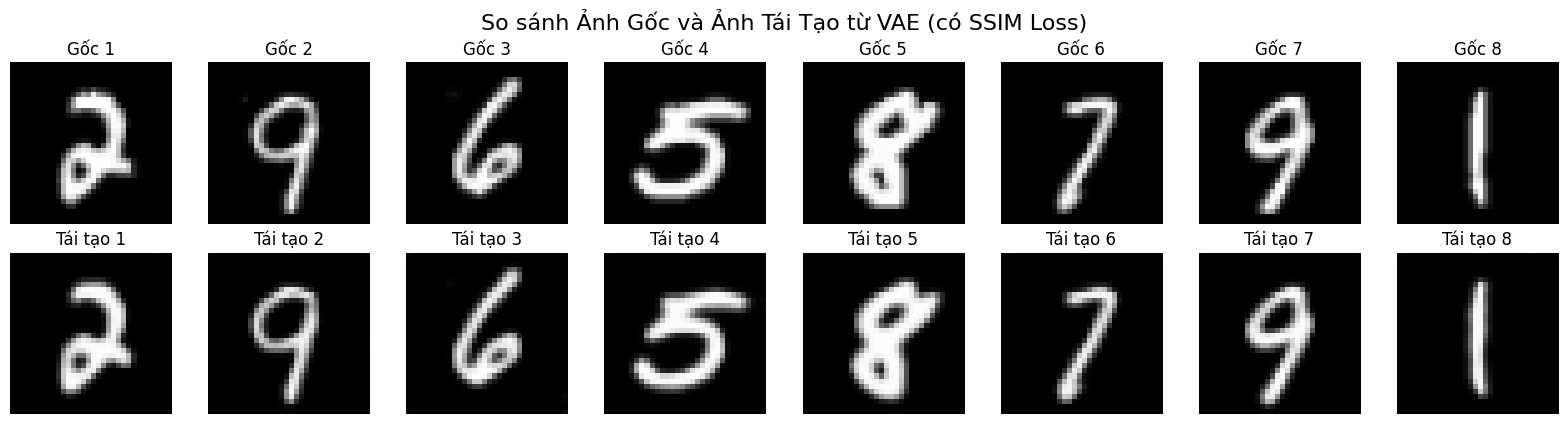

In [18]:
import torch
import matplotlib.pyplot as plt

model.eval()

# Lấy 1 batch dữ liệu ngẫu nhiên
sample_batch = next(iter(val_loader))
images_real = sample_batch['image'].to(device)

# Đưa ảnh gốc qua mô hình
with torch.no_grad():
    images_output, mu_output, log_var_output = model(images_real)

# Chuyển tensor về dạng numpy trên cpu
images_real = images_real.cpu().squeeze().numpy() # (1, 32, 32) -> (32, 32)
images_output = images_output.cpu().squeeze().numpy()

# Chọn số lượng ảnh muốn hiển thị
n_samples = 8
fig, axes = plt.subplots(2, n_samples, figsize=(16,4))

for i in range(n_samples):
    # Hàng 1: Ảnh gốc
    axes[0, i].imshow(images_real[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"Gốc {i+1}")
    axes[0, i].axis('off')

    # Hàng 2: Ảnh tái tạo
    axes[1, i].imshow(images_output[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"Tái tạo {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle("So sánh Ảnh Gốc và Ảnh Tái Tạo từ VAE (có SSIM Loss)", fontsize=16, y=1.05)
plt.show()


Test model sinh ra ảnh mới

In [19]:
# Inference của model
import torch
import matplotlib.pyplot as plt

print("=== SINH ẢNH MỚI TỪ NHIỄU NGẪU NHIÊN (INFERENCE) ===")

# Khởi tạo z: shape(Batch, Channels, Height, Width)
num_images = 4
z = torch.randn(num_images, 4, 4, 4).to(device)
print(f"Ảnh 1: \n{z[0]}")

=== SINH ẢNH MỚI TỪ NHIỄU NGẪU NHIÊN (INFERENCE) ===
Ảnh 1: 
tensor([[[-5.2848e-01,  1.2751e+00,  4.8335e-01, -9.1332e-02],
         [-7.7434e-01,  9.5937e-01,  7.9232e-01,  6.3963e-01],
         [ 1.0729e+00, -9.5313e-01, -6.1294e-01,  7.6299e-01],
         [-7.9572e-02, -1.2190e+00, -1.5701e+00, -1.9430e+00]],

        [[ 2.3136e+00,  8.6147e-01,  1.0314e-01,  1.0355e+00],
         [ 6.1175e-01,  5.5813e-01,  1.7229e+00,  9.4802e-01],
         [-3.1231e-01, -6.6486e-01,  1.4877e+00, -5.3843e-01],
         [-1.7218e+00,  1.4001e-02, -5.2900e-02,  1.3553e+00]],

        [[-1.1627e+00,  1.3281e-01, -6.1137e-01, -8.1763e-01],
         [-1.1986e+00, -6.3036e-02,  1.3061e+00, -5.1937e-01],
         [ 9.5749e-02, -1.4559e-01,  1.1532e+00,  6.2918e-01],
         [ 3.1342e-02,  7.8849e-01, -5.7382e-01,  8.0552e-02]],

        [[-8.5857e-01, -3.6377e-02,  3.0345e-01,  2.7252e-01],
         [-1.4396e+00, -1.3024e+00,  1.2832e-01, -5.6698e-01],
         [-9.1984e-01, -1.4594e+00, -1.9607e-03,  8

In [20]:
# Gọi model
model.eval()
with torch.no_grad():
    gpu_output = model.decoder(z)
    # Đưa output lên cpu để vẽ
    generated_images = gpu_output.to(device='cpu')

print(f"Kích thước ảnh sinh ra (Đầu ra Decoder):     {generated_images.shape}")

Kích thước ảnh sinh ra (Đầu ra Decoder):     torch.Size([4, 1, 32, 32])


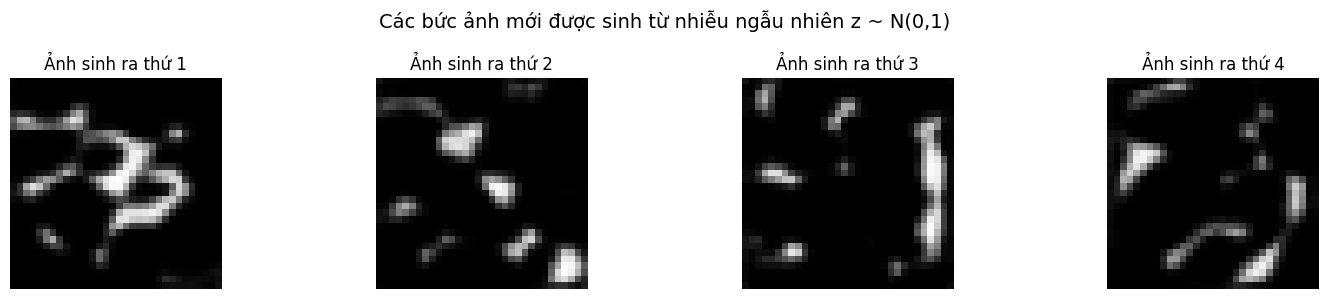

In [21]:
# Trực quan hóa kết quả
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
for i in range(num_images):
    # Ép tensor (1, 32, 32) về mảng 2D (32, 32)
    img_to_show = generated_images[i].squeeze().numpy() 
    
    # Vẽ ảnh
    axes[i].imshow(img_to_show, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Ảnh sinh ra thứ {i+1}")
    axes[i].axis('off')

plt.suptitle("Các bức ảnh mới được sinh từ nhiễu ngẫu nhiên z ~ N(0,1)", fontsize=14)
plt.tight_layout()
plt.show()

Latent Traversel

=== LATENT TRAVERSAL: DÒ TÌM Ý NGHĨA CÁC ĐẶC TRƯNG ===


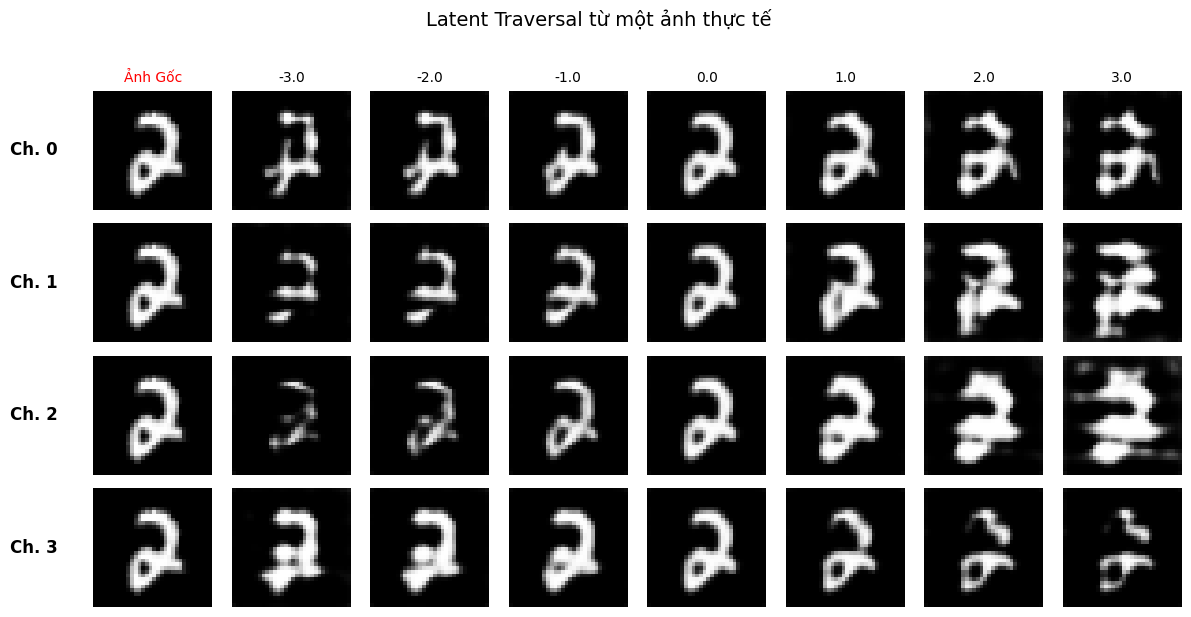

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np

print("=== LATENT TRAVERSAL: DÒ TÌM Ý NGHĨA CÁC ĐẶC TRƯNG ===")
model.eval()

latent_features = config['latent_features']
steps = 7
traversal_range = torch.linspace(-3, 3, steps=steps)

# Lấy 1 bức ảnh từ dataset
sample_batch = next(iter(val_loader))
real_img = sample_batch['image'][0:1].to(device) # lấy ảnh đầu tiên trong batch

with torch.no_grad():
    _, z_base, _ = model(real_img)

    # Chuẩn bị khung vẽ: Cột đầu tiên sẽ để in ảnh gốc
    fig, axes = plt.subplots(latent_features, steps + 1, figsize=(1.5 * (steps + 1), 1.5 * latent_features))

    for c in range(latent_features):
        # Cột 0: Vẽ ảnh gốc
        ax_real = axes[c, 0]
        ax_real.imshow(real_img.cpu().squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        ax_real.axis('off')
        if c == 0:
            ax_real.set_title("Ảnh Gốc", fontsize=10, color='red')
        ax_real.text(-0.3, 0.5, f"Ch. {c}", transform=ax_real.transAxes, 
                     fontsize=12, fontweight='bold', va='center', ha='right')
        
        for i, val in enumerate(traversal_range):
            z = z_base.clone()

            z[0, c, :, :] += val.item()

            generated_img = model.decoder(z)
            img_to_draw = generated_img.cpu().squeeze().numpy()

            ax = axes[c, i+1] 
            ax.imshow(img_to_draw, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            
            if c == 0:
                ax.set_title(f"{val.item():.1f}", fontsize=10)

plt.suptitle(f"Latent Traversal từ một ảnh thực tế", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Trực quan kiến trúc VAE và dữ liệu

In [15]:
model = VAE(latent_features=config['latent_features'])
# 1. In tổng quan kiến trúc (Các layer và tham số)
print("=== KIẾN TRÚC TỔNG QUAN CỦA VAE ===")
print(model)

=== KIẾN TRÚC TỔNG QUAN CỦA VAE ===
VAE(
  (encoder): Encoder(
    (conv0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (resnet1): ResNetBlock(
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (resnet2): ResNetBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))


In [16]:
# 2. In sự thay đổi kích thước dữ liệu khi đi qua mô hình
print("\n=== KÍCH THƯỚC DỮ LIỆU QUA TỪNG BƯỚC ===")
model.to(device)
# Ảnh đầu vào: (batch = 1, 1 kênh màu, 32x32)
dummy_input = torch.randn(1, 1, 32, 32).to(device)

# Truyền qua encoder
mu, log_var = model.encoder(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output của Encoder (mu): {mu.shape}")
print(f"Output của Encoder (log_var): {log_var.shape}")

# Lấy mẫu z
z = reparameterization_trick(mu=mu, log_var=log_var)
print(f"Latent vector (z) shape: {z.shape}")

# Truyền qua Decoder
output = model.decoder(z)
print(f"Output của Decoder: {output.shape}")


=== KÍCH THƯỚC DỮ LIỆU QUA TỪNG BƯỚC ===
Input shape: torch.Size([1, 1, 32, 32])
Output của Encoder (mu): torch.Size([1, 4, 4, 4])
Output của Encoder (log_var): torch.Size([1, 4, 4, 4])
Latent vector (z) shape: torch.Size([1, 4, 4, 4])
Output của Decoder: torch.Size([1, 1, 32, 32])


In [17]:
print("=== REPARAMETERIZATION TRICK ===")
stdev = torch.exp(0.5 * log_var)
epsilon = torch.randn_like(mu)
z_sample = mu + stdev*epsilon

print(f"1. Giá trị trung bình (muy): \n{mu[0, :5].detach().cpu().numpy()}")
print(f"2. Độ lệch chuẩn (stdev): \n{stdev[0, :5].detach().cpu().numpy()}")
print(f"3. Nhiễu epsilon (N(0,1)) sinh ra ngẫu nhiên: \n{epsilon[0, :5].detach().cpu().numpy()}")
print(f"4. Vector tiềm ẩn z (z = mu + stdev * epsilon): \n{z_sample[0, :5].detach().cpu().numpy()}")

=== REPARAMETERIZATION TRICK ===
1. Giá trị trung bình (muy): 
[[[-5.7127718e-02  9.9669978e-02 -3.2037646e-01 -1.0330452e-01]
  [ 2.0569524e-01  3.0492318e-01  2.3345368e-01  4.3289834e-01]
  [ 1.0476431e-01  9.0378553e-02  1.7388617e-01  1.0129231e-01]
  [-1.4770775e-01  3.8392845e-01  9.7995073e-02 -4.6522528e-01]]

 [[ 4.9693666e-02 -3.4377351e-01  2.0662330e-01  2.8615990e-01]
  [ 8.7129116e-02 -1.9831482e-01  1.1775624e-01  5.2159578e-01]
  [-1.7635779e-01 -1.2663524e-01  5.0995700e-02  2.5267583e-01]
  [ 1.0208138e-01  5.0684023e-01  5.1702088e-01  1.4677082e-01]]

 [[ 1.5125071e-01  3.7621580e-02  1.1744939e-02 -1.4031325e-01]
  [-2.5061336e-01 -7.3042110e-02 -3.6585814e-01  3.0622813e-01]
  [-3.3318058e-01 -4.4841564e-01 -2.5326082e-01 -6.5773213e-01]
  [-1.1365877e-01 -2.4376756e-02 -6.0101107e-02 -3.4536225e-01]]

 [[-8.0842659e-02 -3.0670809e-03  1.5106691e-01  2.6469913e-01]
  [ 8.8146001e-02  8.7229878e-02 -1.9968884e-01 -2.1574636e-01]
  [-1.1367603e-01 -7.7646330e-02  1

In [18]:
print("\n=== CHI TIẾT HÀM LOSS ===")
# Giả lập tính loss với ảnh thật và ảnh được tái tạo
batch_fake = torch.randn(16, 1, 32, 32).to(device=device)
output, mu_out, log_var_out = model(batch_fake)

rec_loss = F.l1_loss(output, batch_fake)
kl_loss = 0.5 * torch.sum(mu_out*mu_out + log_var_out.exp() - log_var_out - 1, dim=(1, 2, 3))
kl_loss = torch.mean(kl_loss)

print(f"Reconstruction Loss (Lỗi tái tạo L1): {rec_loss.item():.4f}")
print(f"KL Divergence Loss (Độ lệch phân phối): {kl_loss.item():.4f}")
print(f"Total Loss (Tổng 2 loss): {(rec_loss + kl_loss).item():.4f}")


=== CHI TIẾT HÀM LOSS ===
Reconstruction Loss (Lỗi tái tạo L1): 0.8919
KL Divergence Loss (Độ lệch phân phối): 2.6733
Total Loss (Tổng 2 loss): 3.5652


Trực quan dữ liệu

=== HÌNH DẠNG DỮ LIỆU ĐẦU VÀO ===
Kích thước 1 batch: torch.Size([128, 1, 32, 32])
Giải thích: (Batch_size=128, Số_kênh_màu=1, Chiều_cao=32, Chiều_rộng=32)



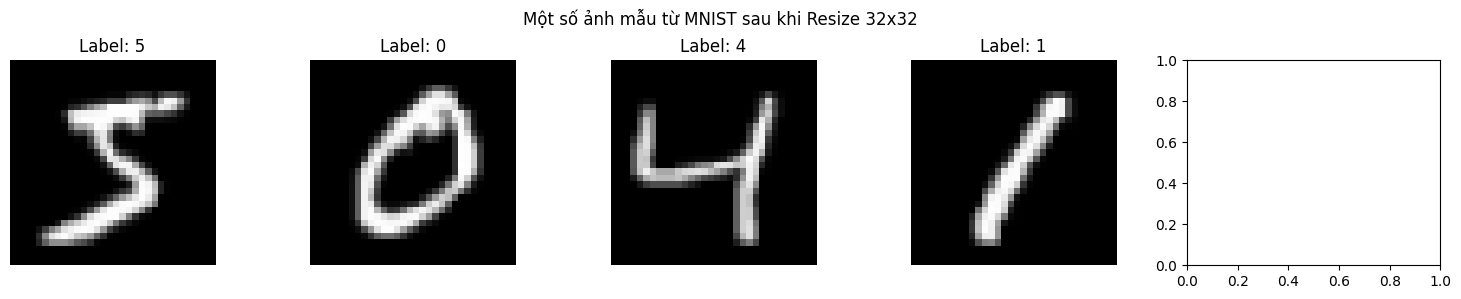

In [19]:
import matplotlib.pyplot as plt

# lấy 1 batch dữ liệu đầu tiên
sample_batch = next(iter(train_loader))
images = sample_batch['image'].cpu()
labels = sample_batch['label'].cpu()

print("=== HÌNH DẠNG DỮ LIỆU ĐẦU VÀO ===")
print(f"Kích thước 1 batch: {images.shape}")
print("Giải thích: (Batch_size=128, Số_kênh_màu=1, Chiều_cao=32, Chiều_rộng=32)\n")

# Vẽ thử 4 ảnh đầu tiên trong batch
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(4):
    # images[i] có shape (1, 32, 32), cần squeeze() để về (32, 32) vẽ bằng matplotlib
    img_to_show = images[i].squeeze().numpy()
    # Vẽ ảnh
    axes[i].imshow(img_to_show, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.suptitle("Một số ảnh mẫu từ MNIST sau khi Resize 32x32")

plt.tight_layout() # Tự động căn chỉnh khoảng cách
plt.show()
